# Plasma_Example_2 — 激光驱动等离子体尾场 (需本地 laser.dat)

本 notebook 是官方算例系列示例之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Plasma_Example_2"
STEM = "plasma"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Plasma_Example_2 | 物理: 激光驱动等离子体尾场 (需本地 laser.dat)


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

  laser.dat 图头计数已转为整数形式
 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Wed Aug 19 21:41:23 

     Working File is:    phsp.in                                           
     Initializing       1000      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =       1000
     total charge                      Q =    -1.0000E-04 nC
     horizontal beam position          x =     1.7439E-07 mm
     vertical beam position            y =     1.5831E-08 mm
     longitudinal beam position        z =     3.0448E-11 m
     horizontal beam size          sig x =     1.5786E-03 mm
     vertical beam size            sig y =     1.5796E-03 mm
     longitudinal beam size  

/Users/yuxinwu/my_projects/astra_notebook/examples/_examples_spec.py:119: UserWarning: fix_laser_map_header 就地改写文件 /Users/yuxinwu/my_projects/astra_notebook/data/workspace/Plasma_Example_2/laser.dat (仅头 3 行计数取整, 数据不动); 原始 DESY 头形式将被覆盖, 请确认已有备份
  fix_laser_map_header(work / "laser.dat")


 --------------------------------------------------------------------------

                     Astra- A space charge tracking algorithm     
               Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
                              DESY,  Hamburg 2022                 
                         19. 8.2026  21:41

     Parameter file is:  plasma.in                                         
                                                                                     

 Initialize element settings:
     neglecting space charge forces 

 --------------------------------------------------------------------------
 Cavity:

     Reading cavity field data from:      PLASMA_flattop.txt                                                              
     Cavity Frequency               f =    0.000     GHz
     Plasma density                 n =   1.0000E+17 cm^-3
     Plasma periode                       1.0559E-04 m
     Plasma starts at                     2.4000E-03 m
     Plasma 

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: plasma.0011.001

  Plasma_Example_2 @ plasma.0011.001
  Particles:           1000 total,     1000 active,      0 passive,
                         0 lost,      0 not started
  Total charge:        0.0001 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:     423.0466 MeV/c
  Ref. kinetic E:    422.5359 MeV
  gamma:             827.8822
  beta:              0.999999
----------------------------------------
  Centroid x:         -0.0001 mm
  Centroid y:          0.0000 mm
  Centroid z:        110.0000 mm
  sigma_x:             0.0028 mm
  sigma_y:             0.0027 mm
  sigma_z:             0.0010 mm
----------------------------------------
  Mean pz:           422.2795 MeV/c
  sigma_p/p:         0.027033
  Mean E_kin:        421.7688 MeV
  sigma_E:         11415.4003 keV
  sigma_E/E:         0.027066
----------------------------------------
  eps_x (geom):        0.0002 um.rad
  eps_y (geom):        0.0002 um.rad
  eps_nx:             

quantity,value,unit
n_particle,1000,
n_active,1000,
n_passive,0,
n_lost,0,
n_not_started,0,
total_charge_nC,0.0001 (|Q|),nC
mean_x_mm,-5.32729e-05,mm
mean_y_mm,9.65013e-06,mm
mean_z_mm,110,mm
sig_x_mm,0.00275748,mm


### 示例要点

File_A0=laser.dat 定义驱动激光 3D 图 (65MB, gitignored)。展示激光轴上剖面与等离子体响应。

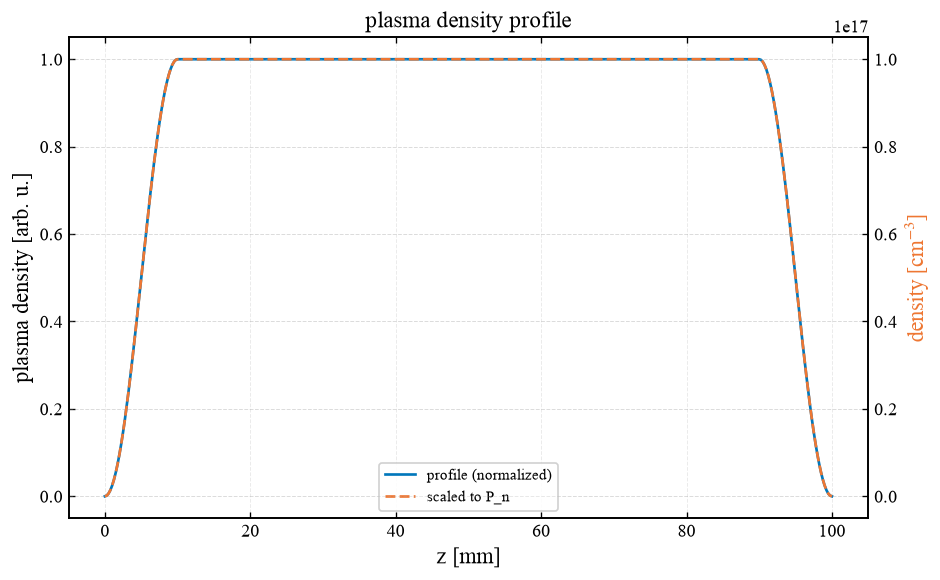

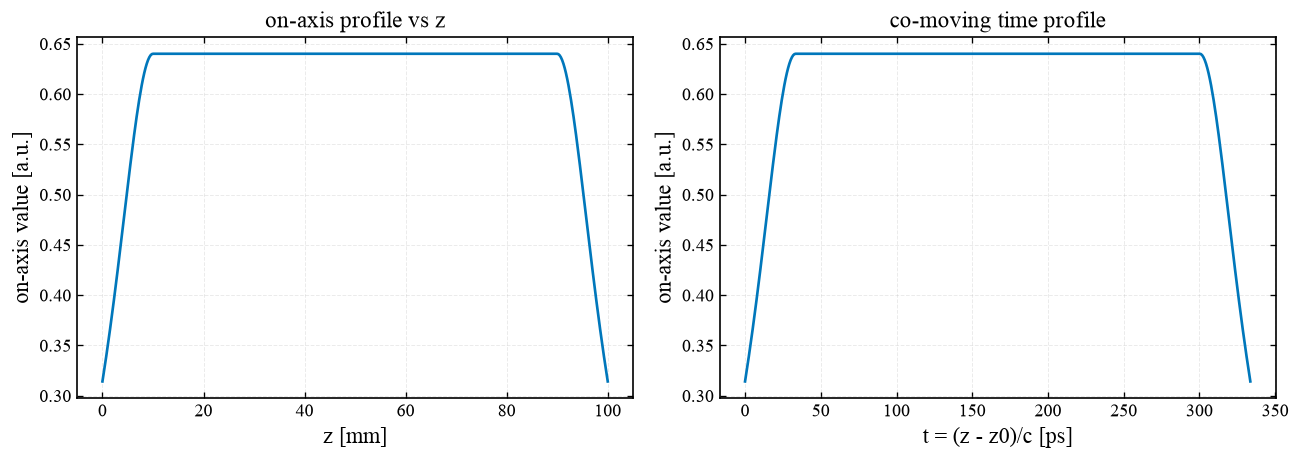

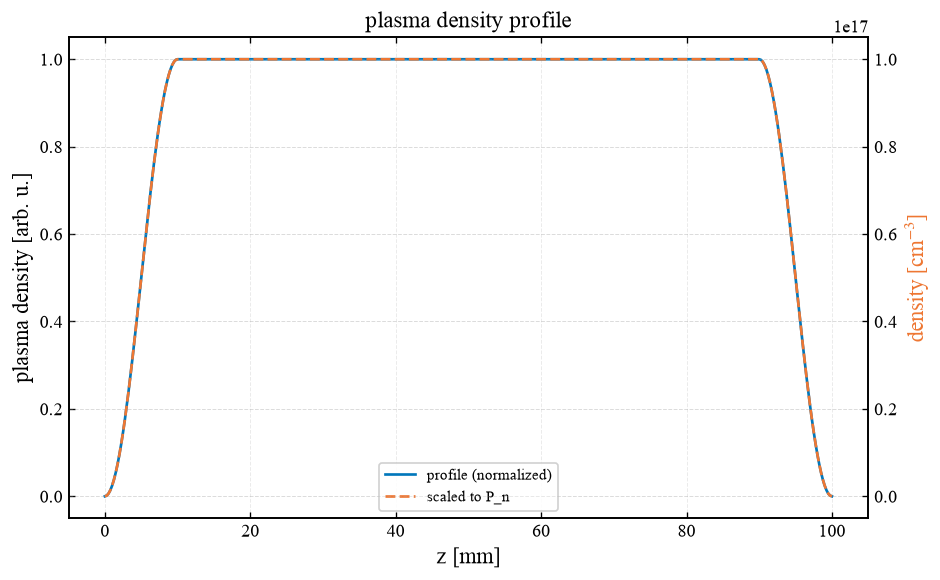

In [5]:
from astra_tools.plot.advanced_plots import plot_laser_on_axis, plot_plasma_profile
laser = work / "laser.dat"
if laser.exists():
    plot_laser_on_axis(laser, unit="a.u.")
else:
    print("laser.dat 不存在 — 请从 DESY 下载 plasma_user_laser.zip")
plot_plasma_profile(work / "PLASMA_flattop.txt", peak_density_cm3=1e17)

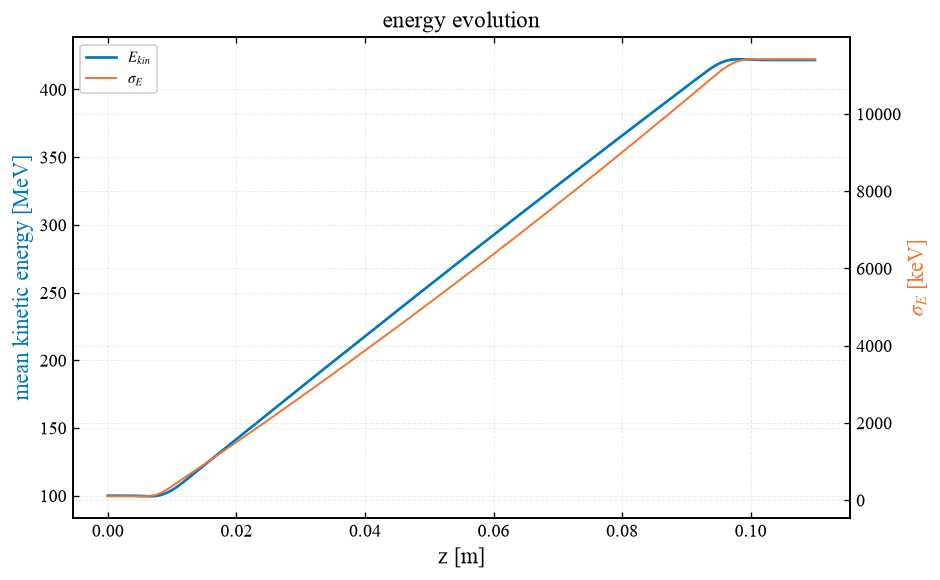

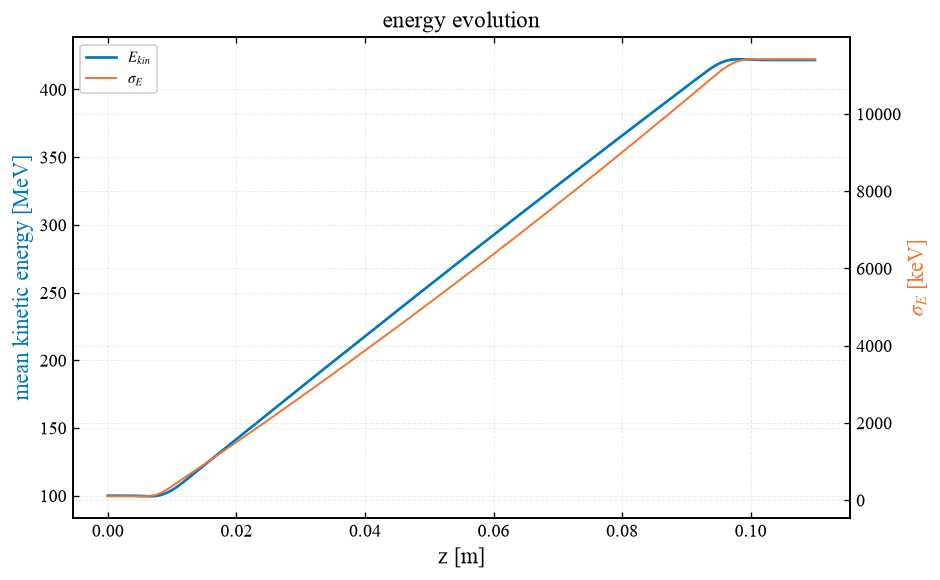

In [6]:
from astra_tools.io.astra_emit import read_emit_files
from astra_tools.plot.emit_plots import plot_energy_evolution
emit = read_emit_files(str(work / STEM))
plot_energy_evolution(emit)

In [7]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的示例 notebook 同样位于 examples/ 目录")

  护栏: Xemit 行数 new=300 golden=300
  护栏: 末行 z=0.11 vs ZSTOP=0.11 (rel=0.0000%)
  末行比对 (new vs golden):
    norm_emit_x    1.5614e-07 1.5614e-07 rel=0.0000% OK
    sigma_x        2.7575e-06 2.7575e-06 rel=0.0000% OK
    mean_z         0.11       0.11       rel=0.0000% OK
  总体: OK
其他官方算例的示例 notebook 同样位于 examples/ 目录
